In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("/kaggle/input/datasets/hngkininh/final-comment-data/final_segment_data.csv")

# Thống kê độ dài comment (tính bằng số từ)
doc_lengths = [len(str(text).split()) for text in df['comment']]
max_seq_len = int(np.percentile(doc_lengths, 95))
print(f"Độ dài tối ưu (95th percentile): {max_seq_len}")

# Thống kê số lượng từ duy nhất
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['comment'])
total_words = len(tokenizer.word_index)
print(f"Tổng số từ vựng duy nhất: {total_words}")

# Thiết lập thông số
MAX_VOCAB_SIZE = min(10000, total_words)
MAX_SEQUENCE_LENGTH = max_seq_len
EMBEDDING_DIM = 64

Độ dài tối ưu (95th percentile): 43


2026-04-02 07:44:50.354795: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775115890.599606      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775115890.673197      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775115891.265005      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775115891.265054      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775115891.265059      55 computation_placer.cc:177] computation placer alr

Tổng số từ vựng duy nhất: 6150


In [2]:
from sklearn.model_selection import train_test_split

# Chia Test 10% trước
train_val_df, test_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    stratify=df['label_id']
)

# Chia tiếp phần còn lại thành Train (~85%) và Val (~15%)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.15,
    random_state=42,
    stratify=train_val_df['label_id']
)

X_train_raw, y_train = train_df['comment'], train_df['label_id']
X_val_raw, y_val = val_df['comment'], val_df['label_id']
X_test_raw, y_test = test_df['comment'], test_df['label_id']

print(f"Số lượng: Train({len(X_train_raw)}) - Val({len(X_val_raw)}) - Test({len(X_test_raw)})")

Số lượng: Train(7003) - Val(1236) - Test(916)


In [3]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

def preprocess_text(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    return pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

X_train = preprocess_text(X_train_raw)
X_val = preprocess_text(X_val_raw)
X_test = preprocess_text(X_test_raw)

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH),
    Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2, return_sequences=False)),
    BatchNormalization(),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

opt = Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1775115914.796294      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775115914.799156      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/12
219/219 ━━━━━━━━━━━━━━━━━━━━ 53s 187ms/step - accuracy: 0.3735 - loss: 1.5585 - val_accuracy: 0.4563 - val_loss: 1.4727
Epoch 2/12
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 182ms/step - accuracy: 0.5171 - loss: 1.3612 - val_accuracy: 0.8228 - val_loss: 1.3336
Epoch 3/12
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 182ms/step - accuracy: 0.6904 - loss: 1.1215 - val_accuracy: 0.8430 - val_loss: 1.0225
Epoch 4/12
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 182ms/step - accuracy: 0.7875 - loss: 0.9211 - val_accuracy: 0.8600 - val_loss: 0.8125
Epoch 5/12
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 181ms/step - accuracy: 0.8356 - loss: 0.7911 - val_accuracy: 0.8714 - val_loss: 0.7199
Epoch 6/12
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 183ms/step - accuracy: 0.8690 - loss: 0.6964 - val_accuracy: 0.8584 - val_loss: 0.7034
Epoch 7/12
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 183ms/step - accuracy: 0.8890 - loss: 0.6071 - val_accuracy: 0.8722 - val_loss: 0.6482
Epoch 8/12
219/219 ━━━━━━━━━━━━━━━━━━━━ 39s 180ms/step - accuracy: 0.8966 - loss: 0

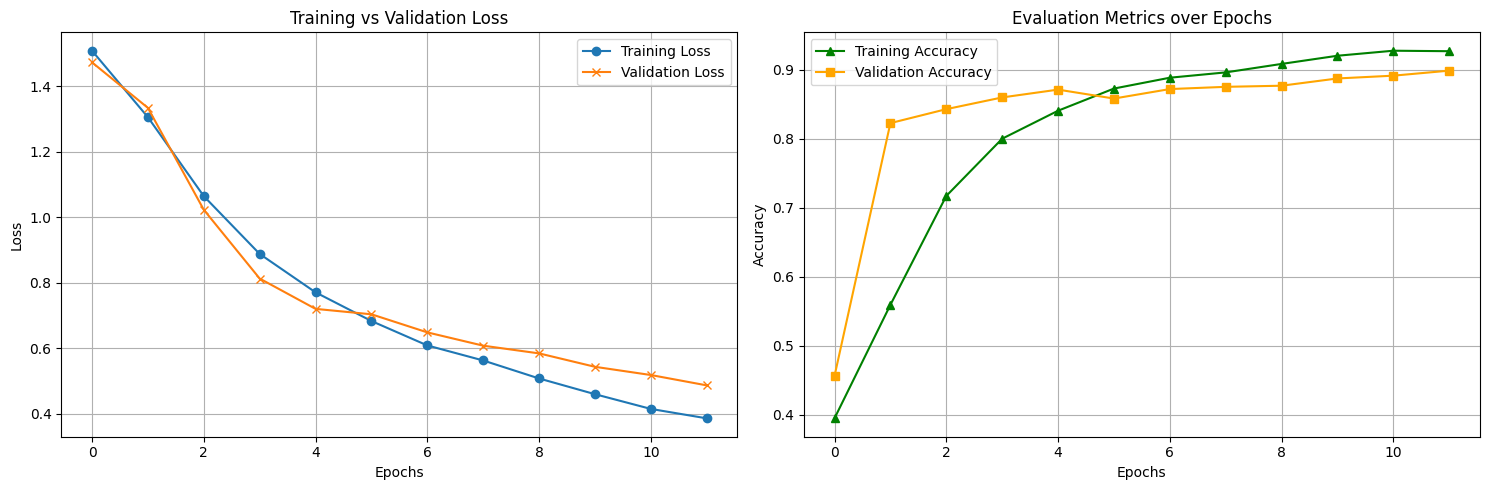

In [5]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.utils import class_weight

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

weights = class_weight.compute_class_weight('balanced',
                                            classes=np.unique(y_train),
                                            y=y_train)
class_weights_dict = dict(enumerate(weights))

history = model.fit(
    X_train, y_train,
    epochs=12,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weights_dict,
    callbacks=[early_stop]
)

# VẼ BIỂU ĐỒ - CÙNG DESIGN LỚN
plt.figure(figsize=(15, 5))

# Left: Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Right: Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green', marker='^')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', marker='s')
plt.title('Evaluation Metrics over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [6]:
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=['CLEAN', 'OFFENSIVE', 'HATE']))

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step
              precision    recall  f1-score   support

       CLEAN       0.92      0.92      0.92       563
   OFFENSIVE       0.87      0.86      0.87       169
        HATE       0.82      0.83      0.82       184

    accuracy                           0.89       916
   macro avg       0.87      0.87      0.87       916
weighted avg       0.89      0.89      0.89       916



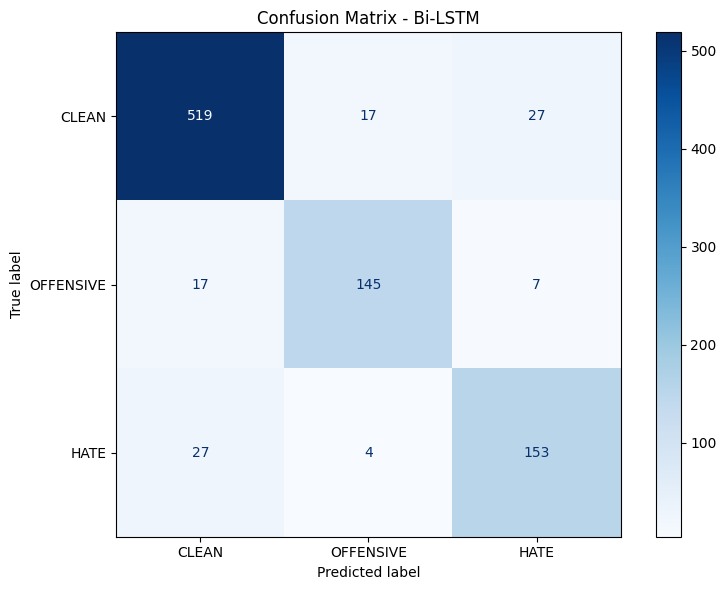

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['CLEAN', 'OFFENSIVE', 'HATE']
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
ax.set_title('Confusion Matrix - Bi-LSTM')
plt.tight_layout()
plt.show()
